<a href="https://colab.research.google.com/github/codewithUswaFatima/urdu-ocr-codesaviours-si26-Uswa/blob/main/SI26_Week2_Uswa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Week 2 – Urdu OCR Image Preprocessing

This notebook preprocesses the Urdu OCR dataset by:

- Loading images
- Converting to grayscale
- Resizing
- Removing noise
- Binarization
- Saving processed images

Finally, Tesseract OCR is tested to understand its limitations on Urdu text.

In [2]:
!pip install opencv-python-headless pillow
import cv2
import numpy as np
from PIL import Image
import os
import glob
import matplotlib.pyplot as plt
print("Libraries imported successfully!")


Libraries imported successfully!


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!unzip -o -q "/content/drive/MyDrive/Urdu_OCR_Project_Data (1) (1).zip" -d /content/

In [5]:
import glob

newspaper = glob.glob("/content/raw/newspaper/**/*.*", recursive=True)
synthetic = glob.glob("/content/raw/synthetic/**/*.*", recursive=True)
dataset = glob.glob("/content/raw/dataset/**/*.*", recursive=True)

print("Newspaper Images:", len(newspaper))
print("Synthetic Images:", len(synthetic))
print("Dataset Images:", len(dataset))
print("Total:", len(newspaper) + len(synthetic) + len(dataset))

Newspaper Images: 32
Synthetic Images: 20
Dataset Images: 50
Total: 102


In [6]:
os.makedirs("/content/processed", exist_ok=True)

In [7]:
import cv2
import os

def preprocess_image(image_path, save_path):

    # Load image
    img = cv2.imread(image_path)

    if img is None:
        print(f"Couldn't load {image_path}")
        return

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Resize image
    resized = cv2.resize(gray, (512, 128))

    # Remove noise
    denoised = cv2.fastNlMeansDenoising(resized, h=10)

    # Convert to black & white
    _, binary = cv2.threshold(denoised, 127, 255, cv2.THRESH_BINARY)

    # Save processed image
    cv2.imwrite(save_path, binary)

    return binary


# Create processed folder
os.makedirs("/content/processed", exist_ok=True)

print("Preprocessing function ready!")

Preprocessing function ready!


In [8]:
import os
from collections import Counter

extensions = Counter()

for root, dirs, files in os.walk("/content/raw"):
    for file in files:
        extensions[os.path.splitext(file)[1].lower()] += 1

print(extensions)

Counter({'.png': 50, '.jpeg': 32, '.jpg': 20})


In [9]:
import shutil
import os

if os.path.exists("/content/processed"):
    shutil.rmtree("/content/processed")

os.makedirs("/content/processed", exist_ok=True)

In [10]:
import glob
import os

all_images = glob.glob("/content/raw/**/*.png", recursive=True)
all_images += glob.glob("/content/raw/**/*.jpg", recursive=True)
all_images += glob.glob("/content/raw/**/*.jpeg", recursive=True)   # <-- Ye line add karo

print("Found", len(all_images), "images")

processed_count = 0

for img_path in all_images:

    filename = os.path.basename(img_path)

    save_path = "/content/processed/" + filename

    result = preprocess_image(img_path, save_path)

    if result is not None:
        processed_count += 1

print("Done! Processed", processed_count, "images")

Found 102 images
Done! Processed 102 images


In [11]:
import os

print("Processed Images:", len(os.listdir("/content/processed")))

Processed Images: 102


In [12]:
!apt-get install -y tesseract-ocr tesseract-ocr-urd
!pip install pytesseract


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following NEW packages will be installed:
  tesseract-ocr-urd
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 1,000 kB of archives.
After this operation, 1,413 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-urd all 1:4.00~git30-7274cfa-1.1 [1,000 kB]
Fetched 1,000 kB in 0s (7,863 kB/s)
Selecting previously unselected package tesseract-ocr-urd.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-urd_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-urd (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-urd (1:4.00~git30-7274cfa-1.1) ...


In [13]:
import pytesseract
from PIL  import Image
import glob

In [14]:
test_images = glob.glob("/content/processed/*.png")
test_images += glob.glob("/content/processed/*.jpg")
test_images += glob.glob("/content/processed/*.jpeg")

test_images = test_images[:5]

print("=====Tesseract OCR Results=====\n")

for img_path in test_images:
  img = Image.open(img_path)
  result = pytesseract.image_to_string(img, lang="urd")
  print("Image:",img_path)
  print("OCR Output:")
  print(result)
  print("-" * 50)

=====Tesseract OCR Results=====

Image: /content/processed/10014.png
OCR Output:
و ا ان ک3 117

--------------------------------------------------
Image: /content/processed/10037.png
OCR Output:
کےا کر ٹاو کے

--------------------------------------------------
Image: /content/processed/10034.png
OCR Output:
افو ین
1
1
"6 ُ
ا

--------------------------------------------------
Image: /content/processed/0.png
OCR Output:
ای کی رر

--------------------------------------------------
Image: /content/processed/10004.png
OCR Output:
2010

--------------------------------------------------


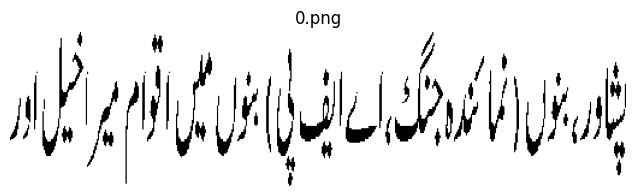

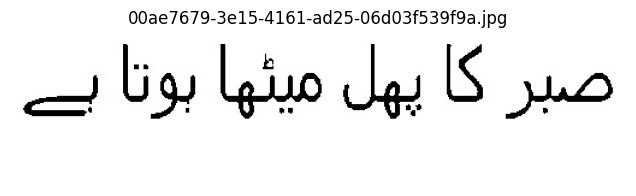

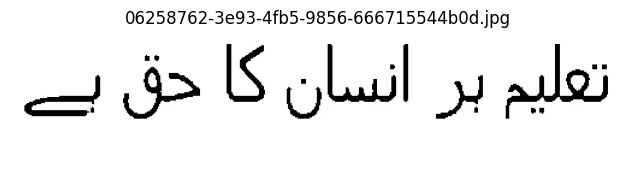

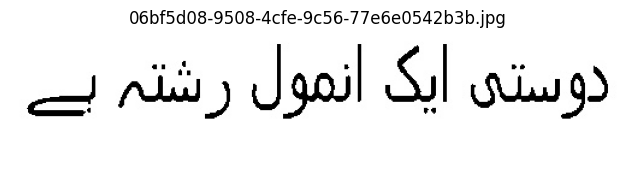

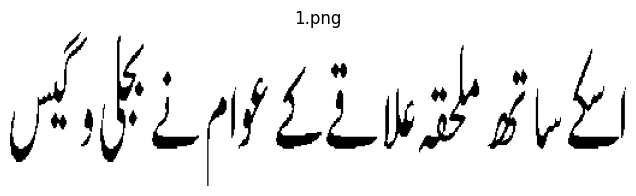

In [16]:
import matplotlib.pyplot as plt
from PIL import Image
import glob

test_images = glob.glob("/content/processed/*.png")
test_images += glob.glob("/content/processed/*.jpg")
test_images += glob.glob("/content/processed/*.jpeg")

test_images = sorted(test_images)[:5]

for img_path in test_images:
    img = Image.open(img_path)

    plt.figure(figsize=(10,2))
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(img_path.split("/")[-1])
    plt.show()

In [17]:
for img_path in test_images:
    img = Image.open(img_path)

    result = pytesseract.image_to_string(img, lang="urd")

    print("Image:", img_path.split("/")[-1])
    print(result)
    print("-"*50)

Image: 0.png
ای کی رر

--------------------------------------------------
Image: 00ae7679-3e15-4161-ad25-06d03f539f9a.jpg
صبر کا پھل میٹھا ہوتا ہے

--------------------------------------------------
Image: 06258762-3e93-4fb5-9856-666715544b0d.jpg
تعلیم بر انسان کا حق ہے

--------------------------------------------------
Image: 06bf5d08-9508-4cfe-9c56-77e6e0542b3b.jpg
دوستی ایک أنمول رشتہ ہے

--------------------------------------------------
Image: 1.png
ءا ملا ےار ابی

--------------------------------------------------


# **Gap Analysis**

### Observation 1
Tesseract was able to recognize some Urdu characters, but many words were incorrect or incomplete.

### Observation 2
The OCR inserted incorrect symbols and numbers in some outputs, reducing readability.

### Observation 3
Several Urdu characters with similar shapes and dots were confused with one another.

### Observation 4
Word spacing and character joining were not handled correctly because Urdu is a cursive script.

### Conclusion
The experiment shows that Tesseract provides only a baseline for Urdu OCR. Although it recognizes some text, it produces many recognition errors, missing characters, incorrect words, and spacing mistakes. These results highlight the need for a machine learning model specifically trained on Urdu text to achieve higher OCR accuracy.